In [35]:
import numpy as np
import pandas as pd

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.tree import DecisionTreeClassifier


In [37]:
df = pd.read_csv('/content/train.csv')

In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# pipeline plan

### [Missing Impute] ➡ [One Hot Encoding(Sex, Embarked)] ➡ [Scaling] ➡ [Feature Selection] ➡ [Model Train]

In [39]:
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace = True)

In [40]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Survived']),
                                                    df['Survived'],
                                                    test_size=0.2,
                                                    random_state=42)

In [41]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S


In [42]:
y_train.head()

,Survived
331,0
733,0
382,0
704,0
813,0


In [43]:
X_train.sample()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
298,1,male,NaN,0,0,30.5,S


## imputation transformer

In [44]:
trf1 = ColumnTransformer([
    ('impute_age', SimpleImputer(), [2]),
    ('impute_embarked', SimpleImputer(strategy='most_frequent'), [6]) # pipeline create krte time index use krna chaiye instead of column name kyu ki jb hm transformation apply krte h to wo ek numpy array hota h jisme column ka name nhi hota h isliye uska index use krna chaiye
], remainder='passthrough')

## One Hot Encoding

In [45]:
trf2 = ColumnTransformer([
    ('ohe_sex_embarked', OneHotEncoder(sparse_output=False, handle_unknown='ignore'),[1,6])
], remainder='passthrough')

## Scaling


In [46]:
trf3 = ColumnTransformer([
    ('scale', MinMaxScaler(), slice(0,10))
])

## Feature Selection

### How chi2(χ²) is calculated

For each feature, the test compares:

Observed (O): What actually appears in the data.
Expected (E): What we would expect if the feature and the target were completely unrelated.

The formula is:

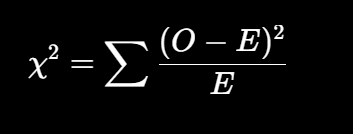
	​


Where:

O = Observed frequency  
E = Expected frequency

In [47]:
trf4 = SelectKBest(score_func = chi2, k = 8)

## Train the Model

In [48]:
trf5 = DecisionTreeClassifier()

## Create pipeline


In [49]:
pipe = Pipeline([
    ('trf1', trf1),
    ('trf2', trf2),
    ('trf3', trf3),
    ('trf4', trf4),
    ('trf5', trf5)
])

In [50]:
# make pipeline
# pipe = make_pipeline (trf1, trf2, trf3, trf4, trf5)

In [51]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_age', SimpleImputer(),
                                                  [2]),
                                                 ('impute_embarked',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [6])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_sex_embarked',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 6])])),
                ('trf3',
                 ColumnTransformer(transformers=[('scale', MinMaxScaler(),
                                                  slice(0, 10, None))])),
                ('trf4',
                 SelectKBest(k=8,
                             score_func=<function chi2 at 0x77fdbde89c60>)),
                ('trf5', DecisionTreeClassifier())])

In [52]:
pipe.named_steps

{'trf1': ColumnTransformer(remainder='passthrough',
                   transformers=[('impute_age', SimpleImputer(), [2]),
                                 ('impute_embarked',
                                  SimpleImputer(strategy='most_frequent'),
                                  [6])]),
 'trf2': ColumnTransformer(remainder='passthrough',
                   transformers=[('ohe_sex_embarked',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  [1, 6])]),
 'trf3': ColumnTransformer(transformers=[('scale', MinMaxScaler(), slice(0, 10, None))]),
 'trf4': SelectKBest(k=8, score_func=<function chi2 at 0x77fdbde89c60>),
 'trf5': DecisionTreeClassifier()}

In [53]:
# Display Pipeline

from sklearn import set_config
set_config(display='diagram')

In [54]:
y_pred = pipe.predict(X_test)

In [55]:
y_pred

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0])

In [56]:
# accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6256983240223464

In [57]:
# cross validation
from sklearn.model_selection import cross_val_score
cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean()

np.float64(0.6391214419383433)

In [58]:
# grid search
# gridsearchcv
params = {
    'trf5__max_depth':[1,2,3,4,5,None]
}

In [59]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('trf1',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('impute_age',
                                                                         SimpleImputer(),
                                                                         [2]),
                                                                        ('impute_embarked',
                                                                         SimpleImputer(strategy='most_frequent'),
                                                                         [6])])),
                                       ('trf2',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe_sex_embarked',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         [1,
                                                                          6])])),
                                       ('trf3',
                                        ColumnTransformer(transformers=[('scale',
                                                                         MinMaxScaler(),
                                                                         slice(0, 10, None))])),
                                       ('trf4',
                                        SelectKBest(k=8,
                                                    score_func=<function chi2 at 0x77fdbde89c60>)),
                                       ('trf5', DecisionTreeClassifier())]),
             param_grid={'trf5__max_depth': [1, 2, 3, 4, 5, None]},
             scoring='accuracy')

In [61]:
grid.best_score_

np.float64(0.6391214419383433)

In [62]:
grid.best_params_

{'trf5__max_depth': 2}

## Exporting the pipeline

In [63]:
import pickle
pickle.dump(pipe, open('pipe.pkl', 'wb'))